<a href="https://colab.research.google.com/github/Anandgnamboothiri/Data-Preprocessing-for-machine-learning-practice-/blob/main/Feature_Engineering_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Feature Engineering steps**

feature transformation

      feature scalling

      duplicate removing

      dealing with catogarical data

      dealing with outliers

feature creation

feature selection

feature Extraction

# **FEATURE TRANSFORMATION**

Feature scalling:

    standardization,
    Normalization

# **Standardization (Z-Score Normalization) : making the values to a perticular rage**

xi = xi - mean/sd

and the values we get the mean of new coloum will be zero and standard deviation will be one

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/rakeshrau/social-network-ads')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Anand G.Namboothiri
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rakeshrau/social-network-ads


100%|██████████| 3.27k/3.27k [00:00<00:00, 3.60MB/s]

In [ ]:
data = pd.read_csv('/content/social-network-ads/Social_Network_Ads.csv')
data_df = pd.DataFrame(data)
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
data.columns


Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [ ]:
data.drop(columns=['User ID', 'Gender'],axis=True,inplace=True)

In [ ]:
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
import sklearn
from sklearn.model_selection import train_test_split

x = data.drop(columns=['Purchased'])
y = data['Purchased']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape, y_train.shape


((320, 2), (320,))

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(x_train) # This line calculates the mean and standard deviation ONLY from x_train

# Now, transform both training and test data using the parameters learned from x_train
scaled_x_train = sc.transform(x_train)
scaled_x_test = sc.transform(x_test) # Transform x_test using the parameters from x_train

# Displaying the first few scaled training samples
print("First 5 scaled training samples:")
for i in range(5):
  print(scaled_x_train[i])



First 5 scaled training samples:
[-1.06675246 -0.38634438]
[ 0.79753468 -1.22993871]
[0.11069205 1.853544  ]
[ 0.60129393 -0.90995465]
[ 1.87685881 -1.28811763]


In [ ]:
df_scaled_x_train = pd.DataFrame(scaled_x_train,columns=x_train.columns)
df_scaled_x_test = pd.DataFrame(scaled_x_test,columns=x_test.columns)

# print("First 5 scaled training samples:")
# print(df_scaled_x_train)

print("Descriptive statistics for scaled training data (df_scaled_x_train):")
print(np.round(df_scaled_x_train.describe(),2))

print("\nDescriptive statistics for scaled test data (df_scaled_x_test):")
print(np.round(df_scaled_x_test.describe(),2))

Descriptive statistics for scaled training data (df_scaled_x_train):
          Age  EstimatedSalary
count  320.00           320.00
mean    -0.00             0.00
std      1.00             1.00
min     -1.95            -1.61
25%     -0.77            -0.79
50%     -0.09             0.02
75%      0.70             0.52
max      2.17             2.32

Descriptive statistics for scaled test data (df_scaled_x_test):
         Age  EstimatedSalary
count  80.00            80.00
mean   -0.11            -0.08
std     1.13             0.96
min    -1.95            -1.49
25%    -0.97            -0.80
50%    -0.23            -0.15
75%     0.90             0.38
max     2.17             2.14


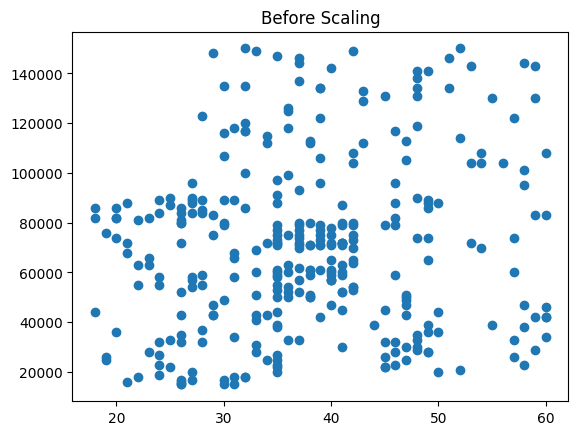

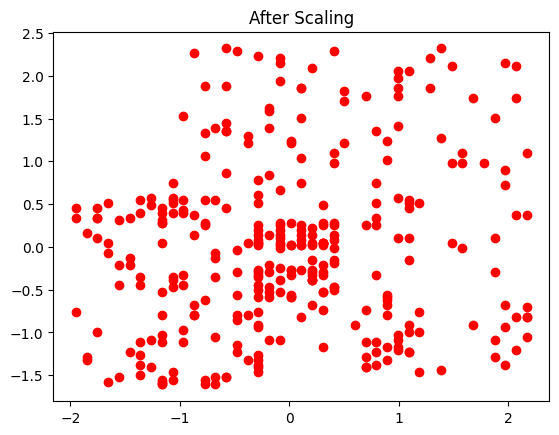

In [ ]:
plt.scatter(x_train['Age'],x_train['EstimatedSalary'])
plt.title('Before Scaling')
plt.show()
plt.scatter(df_scaled_x_train['Age'],df_scaled_x_train['EstimatedSalary'],color = 'red')
plt.title('After Scaling')
plt.show()

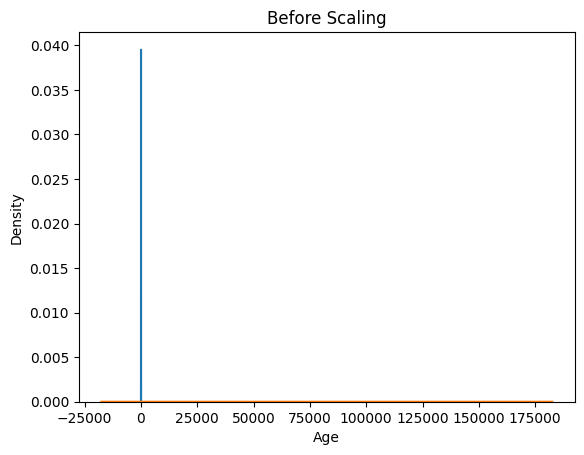

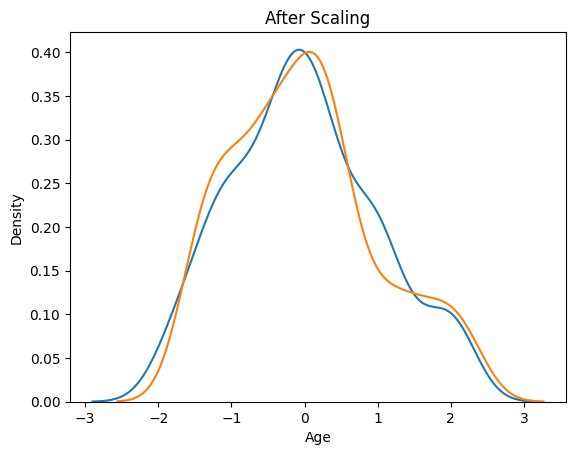

In [ ]:
sns.kdeplot(x_train['Age'])
sns.kdeplot(x_train['EstimatedSalary'])
plt.title('Before Scaling')
plt.show()

sns.kdeplot(df_scaled_x_train['Age'])
sns.kdeplot(df_scaled_x_train['EstimatedSalary'])
plt.title('After Scaling')
plt.show()

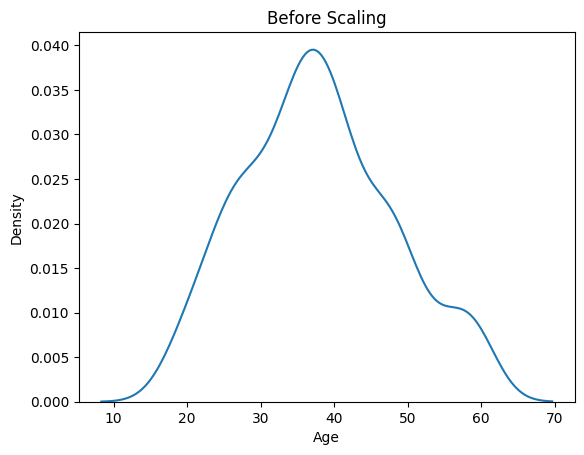

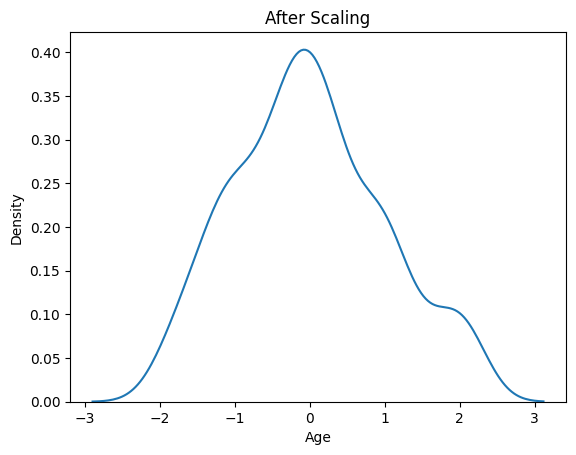

In [ ]:
sns.kdeplot(x_train['Age'])

plt.title('Before Scaling')
plt.show()

sns.kdeplot(df_scaled_x_train['Age'])

plt.title('After Scaling')
plt.show()

# II) **Normalisation ** Mostly used method is MinMax Normalisation

### **formula = Xn = Xi - Xmin/ Xmax - Xmin**

In [ ]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/tawfikelmetwally/wine-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Anand G.Namboothiri
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tawfikelmetwally/wine-dataset


100%|██████████| 4.45k/4.45k [00:00<00:00, 13.7MB/s]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv('/content/wine-dataset/Wine dataset.csv')
data.head()
data.columns
data = pd.DataFrame(data)
data.head()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
data.drop(columns=[ 'Ash', 'Alcalinity of ash',
       'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline '],axis=True,inplace=True)

In [ ]:
data

,class,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


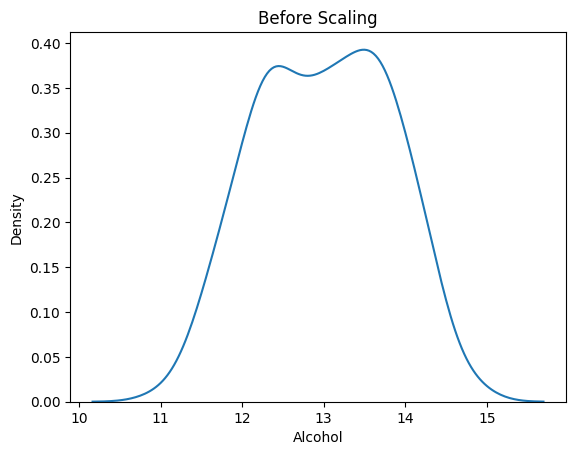

In [ ]:
sns.kdeplot(data['Alcohol'])
plt.title('Before Scaling')
plt.show()

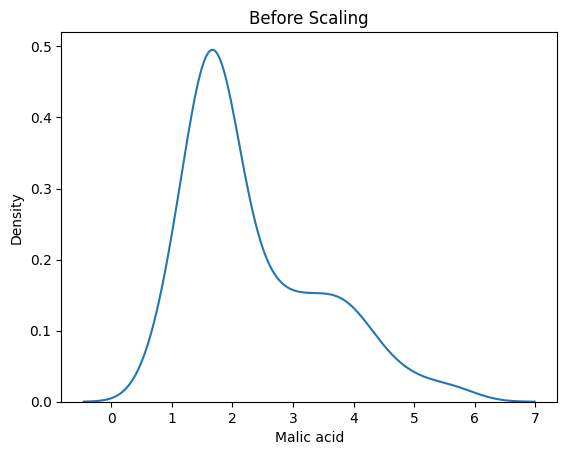

In [ ]:
# The error occurred in cell zOiamF0h58us due to an incorrect train_test_split
# variable assignment in cell jeVg78cS4-Cn.
# The `train_test_split` returned variables in the order (x_train, x_test, y_train, y_test),
# but they were assigned as (x_train, y_train, x_test, y_test).
# This resulted in `x_test` being a pandas Series (target) instead of a DataFrame (features),
# causing MinMaxScaler to raise a ValueError.
# To fix this, please correct the variable assignment in cell jeVg78cS4-Cn to:
# `x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)`
sns.kdeplot(data['Malic acid'])
plt.title('Before Scaling')
plt.show()

In [ ]:
x = data.drop(columns=['class'],axis=True)
y = data['class']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
scaler = MinMaxScaler()

scaler.fit(x_train)

scaled_x_train = scaler.transform(x_train)
scaled_x_test = scaler.transform(x_test)
print(scaled_x_test)

print(data)

[[ 0.68684211  0.45010183]
 [ 0.83684211  0.64154786]
 [ 0.5         0.3910387 ]
 [ 0.71052632  0.12423625]
 [ 0.35263158  0.05702648]
 [ 0.86052632  0.20977597]
 [ 0.25526316  0.51731161]
 [ 0.62368421  0.61507128]
 [ 0.15263158  0.09368635]
 [ 0.61315789  0.3401222 ]
 [ 0.65        0.18737271]
 [ 0.65        0.45417515]
 [ 0.62631579  0.60081466]
 [ 0.45789474  0.51731161]
 [ 0.68421053  0.18737271]
 [ 0.39210526  0.31364562]
 [ 0.1        -0.0305499 ]
 [ 0.27631579  0.04887984]
 [ 0.74473684  0.09368635]
 [ 0.27631579  0.10183299]
 [ 0.83157895  0.14256619]
 [ 0.54736842  0.02443992]
 [ 0.34210526  0.04276986]
 [ 0.62368421  0.75560081]
 [ 0.45789474  0.30549898]
 [ 0.72368421  0.3808554 ]
 [ 0.36578947  0.14663951]
 [ 0.35263158  0.06517312]
 [ 0.27631579  0.19144603]
 [ 0.66578947  0.17107943]
 [ 0.78684211  0.16089613]
 [ 0.35263158  0.15071283]
 [ 0.56052632  0.54582485]
 [ 0.67105263  0.15682281]
 [ 0.71578947  0.17107943]
 [ 0.75        0.20366599]]
     class  Alcohol  Malic 

In [ ]:
df_scaled_x_train = np.round(pd.DataFrame(scaled_x_train),2)
df_scaled_x_test = np.round(pd.DataFrame(scaled_x_test),2)
df_scaled_x_train.describe()


,0,1
count,142.000000,142.000000
mean,0.512817,0.302535
std,0.215901,0.232978
min,0.000000,0.000000
25%,0.340000,0.150000
50%,0.525000,0.200000
75%,0.697500,0.455000
max,1.000000,1.000000


In [ ]:
np.round(df_scaled_x_train.describe(),2)

,0,1
count,142.00,142.00
mean,0.51,0.30
std,0.22,0.23
min,0.00,0.00
25%,0.34,0.15
50%,0.52,0.20
75%,0.70,0.46
max,1.00,1.00


look that when we look the discription of the data by data.describe(), we can actually see that the minimum value has become exactly zero and the maximum value become one

max_value of data(After normalisation) = 1

min_value of data(After normalisation) = 0

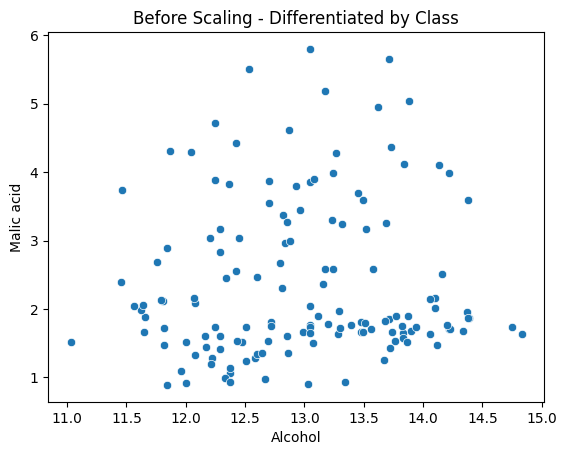

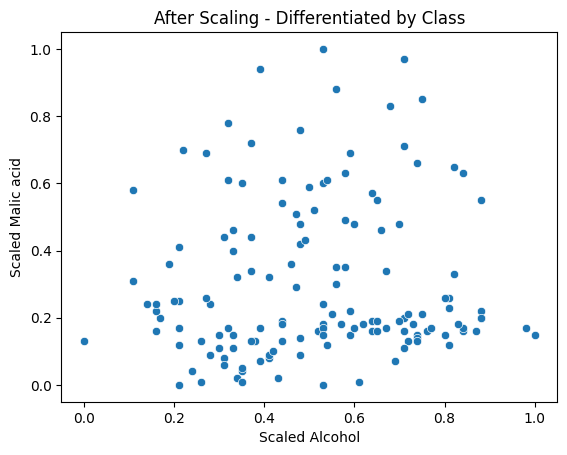

In [ ]:
sns.scatterplot(x=x_train['Alcohol'], y=x_train['Malic acid'])
plt.title('Before Scaling - Differentiated by Class')
plt.xlabel('Alcohol')
plt.ylabel('Malic acid')
plt.show()

sns.scatterplot(x=df_scaled_x_train[0], y=df_scaled_x_train[1])
plt.title('After Scaling - Differentiated by Class')
plt.xlabel('Scaled Alcohol')
plt.ylabel('Scaled Malic acid')
plt.show()

the data has been compressed and the range become 0 to 1

it has enclosed in a squre having area of 1

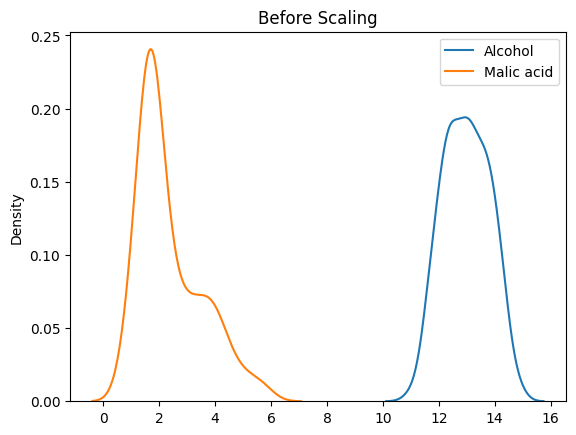

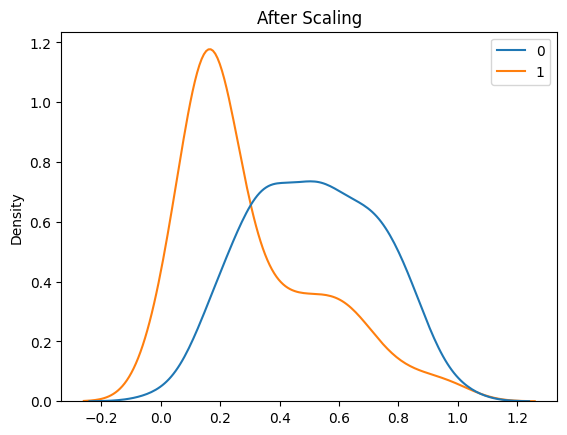

In [ ]:
sns.kdeplot(x_train)
plt.title('Before Scaling')
plt.show()

sns.kdeplot(df_scaled_x_train)
plt.title('After Scaling')
plt.show()

# **Encoding the catogarical data**

## **Catogarical data are two:**

1. Ordinal catagorical data: there will be a order like PG,UG,HS here PG>UG>HS

2.  Nominal data (No order for the data, like the branches of engineering there we cant say this branch is the first and likewise.)





Ordinal Data = ordinal encoder

nominal data = One Hot Encoder

output value (y) encode = LabelEncoder

## **Catogarical Value Handling**

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder
from sklearn.linear_model import LinearRegression

In [ ]:
od.download("https://www.kaggle.com/datasets/sanyamgoyal401/customer-purchases-behaviour-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Anand G.Namboothiri
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sanyamgoyal401/customer-purchases-behaviour-dataset


100%|██████████| 1.45M/1.45M [00:00<00:00, 752MB/s]

In [ ]:
data = pd.read_csv('/content/customer-purchases-behaviour-dataset/customer_data.csv')
data.head(100)

,id,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,promotion_usage,satisfaction_score
0,1,27,Male,40682,Bachelor,East,Gold,frequent,18249,Books,0,6
1,2,29,Male,15317,Masters,West,Regular,rare,4557,Clothing,1,6
2,3,37,Male,38849,Bachelor,West,Silver,rare,11822,Clothing,0,6
3,4,30,Male,11568,HighSchool,South,Regular,frequent,4098,Food,0,7
4,5,31,Female,46952,College,North,Regular,occasional,19685,Clothing,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,27,Female,9697,Masters,West,Silver,frequent,2441,Electronics,0,6
96,97,40,Male,35606,Bachelor,South,Gold,rare,10354,Food,0,6
97,98,37,Male,6856,Bachelor,South,Silver,occasional,2387,Clothing,0,6
98,99,29,Male,5135,Bachelor,East,Regular,rare,1676,Clothing,0,4


In [ ]:
data.shape

(100000, 12)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.dropna(inplace=True)

In [ ]:
data.columns

Index(['id', 'age', 'gender', 'income', 'education', 'region',
       'loyalty_status', 'purchase_frequency', 'purchase_amount',
       'product_category', 'promotion_usage', 'satisfaction_score'],
      dtype='object')

In [ ]:

data.columns

Index(['id', 'age', 'gender', 'income', 'education', 'region',
       'loyalty_status', 'purchase_frequency', 'purchase_amount',
       'product_category', 'promotion_usage', 'satisfaction_score'],
      dtype='object')

In [ ]:
data.head()
#data.drop(columns=['product_category', 'promotion_usage', 'satisfaction_score'],axis=True,inplace=True)
data.shape


(100000, 12)

In [ ]:
ordinal_encoder = OrdinalEncoder(categories=[['HighSchool','College','Bachelor','Masters','Phd'],['Regular','Silver','Gold','Platinum'],['rare','occasional','frequent']],dtype=int)
nominal_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore',drop='first',dtype=int)

ordinal_data = ['education','loyalty_status','purchase_frequency']
nominal_data = ['gender','region']

x = data.drop(columns=['purchase_amount'])
y = data['purchase_amount']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42)




In [ ]:
#ordinal data encoding

oe_tr_d = ordinal_encoder.fit_transform(x_train[ordinal_data])
oe_te_d = ordinal_encoder.fit_transform(x_test[ordinal_data])
oe_tr_d.shape

(80000, 3)

In [ ]:
#nominal encoding

ohe_tr_d = nominal_encoder.fit_transform(x_train[nominal_data])
ohe_te_d = nominal_encoder.fit_transform(x_test[nominal_data])
ohe_tr_d.shape

(80000, 4)

In [ ]:
x_other_data_train = x_train.drop(columns=ordinal_data+nominal_data).values
x_other_data_test = x_test.drop(columns=ordinal_data+nominal_data).values

x_other_data_train

array([[75221, 24, 29205, 'Clothing', 0, 5],
       [48956, 38, 47963, 'Food', 0, 5],
       [44967, 33, 24892, 'Beauty', 0, 5],
       ...,
       [76821, 31, 48960, 'Electronics', 0, 6],
       [861, 34, 9862, 'Electronics', 0, 5],
       [15796, 25, 7212, 'Clothing', 0, 7]], dtype=object)

In [ ]:
trans_data = np.concatenate((x_other_data_train,ohe_tr_d,oe_tr_d),axis=1)
trans_data


In [ ]:
other_columns = ['id','age','income']
nominal_columns = nominal_encoder.get_feature_names_out(nominal_data)
data_transformed = pd.DataFrame(trans_data,columns=other_columns+list(nominal_columns)+ordinal_data,index = x_train.index)

data_transformed.shape

(80000, 10)

# **Column transformation**

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
